# Naive Frequent Pairs — Online Retail

Menghitung **frequent pairs** (pasangan item yang sering muncul bersama) dari dataset *Online Retail* menggunakan **algoritma naive** dengan dua pendekatan penyimpanan hitungan pasangan:

1. **Triangular Matrix** — menyimpan hitungan semua pasangan pada satu array 1-D (indeks segitiga).
2. **Triples / Tuples** — menyimpan hitungan hanya untuk pasangan yang benar-benar muncul sebagai `(i, j, count)`.

Data yang dipakai hanya kolom **`CustomerID`** (sebagai *basket*) dan **`Description`** (sebagai *item*).

Untuk setiap pendekatan ditampilkan:
- **Waktu eksekusi**
- **Jumlah kandidat itemset (pasangan) yang dibangkitkan**
- **Jumlah pass/scan ke database**

In [1]:
import time
from itertools import combinations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Muat data: hanya kolom CustomerID dan Description ---
df = pd.read_excel("Online Retail.xlsx", usecols=["CustomerID", "Description"])

print("Ukuran data mentah:", df.shape)
df.head()

Ukuran data mentah: (541909, 2)


,Description,CustomerID
0,WHITE HANGING HEART T-LIGHT HOLDER,17850.0
1,WHITE METAL LANTERN,17850.0
2,CREAM CUPID HEARTS COAT HANGER,17850.0
3,KNITTED UNION FLAG HOT WATER BOTTLE,17850.0
4,RED WOOLLY HOTTIE WHITE HEART.,17850.0


## 1. Pembersihan data & pembentukan basket

- Buang baris tanpa `CustomerID` atau `Description`.
- Rapikan teks `Description`.
- Kelompokkan item per `CustomerID` menjadi **basket** (himpunan item unik per pelanggan).

In [2]:
# Bersihkan & normalisasi data
n_baris_awal = len(df)

# Anggap kosong: NaN, string kosong, atau hanya spasi
df["Description"] = df["Description"].astype(str).str.strip()
kosong = df["CustomerID"].isna() | df["Description"].isin(["", "nan", "NaN", "None"])
n_kosong = int(kosong.sum())
df = df[~kosong].copy()
df["CustomerID"] = df["CustomerID"].astype(int)

# Normalisasi teks: samakan variasi yang sebenarnya barang yang sama
n_desc_sebelum = df["Description"].nunique()
df["Description"] = (
    df["Description"].astype(str)
      .str.upper()                       # samakan huruf besar/kecil
      .str.replace(r"\s+", " ", regex=True)  # spasi ganda -> satu spasi
      .str.strip()                       # buang spasi tepi
)
df = df[df["Description"] != ""]  # buang lagi bila jadi kosong setelah normalisasi
n_desc_sesudah = df["Description"].nunique()

# Hapus duplikat: satu Description hanya dihitung sekali per CustomerID
n_sebelum_dedup = len(df)
df = df.drop_duplicates(subset=["CustomerID", "Description"]).copy()
n_duplikat = n_sebelum_dedup - len(df)

print(f"Baris data mentah                  : {n_baris_awal}")
print(f"Baris kosong (NaN/kosong) dibuang  : {n_kosong}")
print(f"Duplikat (CustomerID, Description) : {n_duplikat}")
print(f"Baris tersisa                      : {len(df)}")
print(f"Deskripsi unik sebelum normalisasi : {n_desc_sebelum}")
print(f"Deskripsi unik sesudah normalisasi : {n_desc_sesudah}")
print(f"Berkurang (variasi digabung)       : {n_desc_sebelum - n_desc_sesudah}")

# Bentuk basket: himpunan item unik per pelanggan
baskets = (
    df.groupby("CustomerID")["Description"]
      .apply(lambda s: sorted(set(s)))
      .tolist()
)

n_baskets = len(baskets)
print("Jumlah basket (pelanggan):", n_baskets)
print("Rata-rata item unik / basket:", round(sum(len(b) for b in baskets) / n_baskets, 2))
print("Contoh 5 item dalam 1 basket :", baskets[1][:5])

Baris data mentah                  : 541909
Baris kosong (NaN/kosong) dibuang  : 135080
Duplikat (CustomerID, Description) : 137921
Baris tersisa                      : 268908
Deskripsi unik sebelum normalisasi : 3885
Deskripsi unik sesudah normalisasi : 3877
Berkurang (variasi digabung)       : 8
Jumlah basket (pelanggan): 4372
Rata-rata item unik / basket: 61.51
Contoh 5 item dalam 1 basket : ['3D DOG PICTURE PLAYING CARDS', '3D SHEET OF CAT STICKERS', '3D SHEET OF DOG STICKERS', '60 TEATIME FAIRY CAKE CASES', '72 SWEETHEART FAIRY CAKE CASES']


## 2. Pass ke-1 — hitung item tunggal & pemberian ID integer



In [14]:
# Ambang dukungan minimum (jumlah basket) untuk menyebut pasangan "frequent"
MIN_SUPPORT = 100

# ---- PASS 1: scan seluruh basket untuk menghitung item tunggal ----
passes = 0
t0 = time.perf_counter()

item_count = {}
passes += 1  # scan ke-1 ke database
for basket in baskets:
    for item in basket:
        item_count[item] = item_count.get(item, 0) + 1

# Pemetaan item -> ID integer 0..n-1
items = sorted(item_count)
item_to_id = {item: i for i, item in enumerate(items)}
n = len(items)

t_pass1 = time.perf_counter() - t0
print(f"Jumlah pass setelah pass-1  : {passes}")
print(f"Jumlah item unik (n)        : {n}")
print(f"Waktu pass-1                : {t_pass1:.4f} detik")

Jumlah pass setelah pass-1  : 1
Jumlah item unik (n)        : 3877
Waktu pass-1                : 0.0779 detik


## 3. Pendekatan A — Triangular Matrix

Semua pasangan $\{i, j\}$ dengan $i < j$ dipetakan ke satu array 1-D memakai indeks segitiga:

$$k = i \cdot n - \frac{i(i+1)}{2} + (j - i - 1)$$

Jumlah **kandidat pasangan yang dibangkitkan** = seluruh sel matriks segitiga = $\binom{n}{2} = \dfrac{n(n-1)}{2}$, karena metode ini mengalokasikan tempat untuk **setiap** pasangan yang mungkin.

In [15]:

# ---- PASS 2 (Triangular Matrix): hitung semua pasangan ----
tri_passes = passes  # sudah termasuk pass-1
t0 = time.perf_counter()

# Alokasi array segitiga: satu sel untuk tiap pasangan yang mungkin -> kandidat = C(n,2)
tri_candidates = n * (n - 1) // 2
tri = np.zeros(tri_candidates, dtype=np.int32)

def tri_index(i, j, n):
    # i < j, indeks segitiga 0-based
    return i * n - (i * (i + 1)) // 2 + (j - i - 1)

tri_passes += 1  # scan ke-2 ke database
for basket in baskets:
    ids = sorted(item_to_id[item] for item in basket)
    for i, j in combinations(ids, 2):
        tri[tri_index(i, j, n)] += 1

# Kumpulkan pasangan frequent
tri_frequent = []
for i in range(n):
    base = i * n - (i * (i + 1)) // 2 - (i + 1)
    for j in range(i + 1, n):
        c = tri[base + j]
        if c >= MIN_SUPPORT:
            tri_frequent.append((items[i], items[j], int(c)))

t_tri = time.perf_counter() - t0

# Memori struktur penghitung: array int32 padat
tri_mem = tri.nbytes

print("=== Pendekatan A: Triangular Matrix ===")
print(f"Waktu eksekusi (pass-2)         : {t_tri:.4f} detik")
print(f"Kandidat pasangan dibangkitkan  : {tri_candidates:,}  (= C(n,2))")
print(f"Jumlah pass/scan ke database    : {tri_passes}")
print(f"Memori penghitung pasangan      : {tri_mem / 1024**2:.2f} MB")
print(f"Pasangan frequent (>= {MIN_SUPPORT})       : {len(tri_frequent):,}")

=== Pendekatan A: Triangular Matrix ===
Waktu eksekusi (pass-2)         : 15.7510 detik
Kandidat pasangan dibangkitkan  : 7,513,626  (= C(n,2))
Jumlah pass/scan ke database    : 2
Memori penghitung pasangan      : 28.66 MB
Pasangan frequent (>= 100)       : 2,428


## 3a. Simulasi batas main memory 20 MB — Pendekatan 1 (Triangular Matrix)

Triangular Matrix mengalokasikan **satu sel `int32` (4 byte) untuk setiap pasangan yang mungkin**, yaitu $\binom{n}{2}$ sel. Dengan $n = 3877$ item, kebutuhannya $\approx 28,66$ MB sehingga **tidak muat** pada main memory yang dibatasi **20 MB**.

Simulasi ini:
1. Menetapkan anggaran memori **20 MB**.
2. Menghitung **jumlah item maksimum** yang bisa ditampung dalam 20 MB.
3. Menyaring hanya item paling sering (single-item support tertinggi) sebanyak batas tersebut, lalu **menjalankan Pendekatan 1** pada subset item itu agar tetap muat di 20 MB.


In [16]:
# ---- Simulasi: main memory dibatasi 20 MB, jalankan Pendekatan 1 (Triangular Matrix) ----
MAIN_MEMORY_MB = 20
budget_bytes = MAIN_MEMORY_MB * 1024**2
bytes_per_cell = np.dtype(np.int32).itemsize  # 4 byte

# Kebutuhan penuh untuk semua item
full_cells = n * (n - 1) // 2
full_bytes = full_cells * bytes_per_cell

print(f"Main memory tersedia        : {MAIN_MEMORY_MB} MB ({budget_bytes:,} byte)")
print(f"Item unik (n)               : {n:,}")
print(f"Kebutuhan triangular penuh  : {full_cells:,} sel = {full_bytes/1024**2:.2f} MB")

if full_bytes <= budget_bytes:
    m = n
    print("\n=> MUAT: seluruh item bisa ditampung dalam 20 MB.")
else:
    # n maksimum yang muat: n(n-1)/2 * 4 <= budget
    max_cells = budget_bytes // bytes_per_cell
    m = int((1 + (1 + 8 * max_cells) ** 0.5) // 2)
    while m * (m - 1) // 2 * bytes_per_cell > budget_bytes:
        m -= 1
    print(f"\n=> TIDAK MUAT: perlu {full_bytes/1024**2:.2f} MB > {MAIN_MEMORY_MB} MB.")
    print(f"   Item maksimum yang muat dalam 20 MB: {m:,} item.")

# Pilih m item paling sering agar muat di 20 MB, lalu jalankan Pendekatan 1
kept = sorted(
    item_to_id[it] for it, _ in sorted(item_count.items(), key=lambda x: x[1], reverse=True)[:m]
)
old_to_new = {old: new for new, old in enumerate(kept)}   # remap ID lama -> 0..m-1
kept_names = [items[old] for old in kept]

mem_cells = m * (m - 1) // 2
tri20_mem = mem_cells * bytes_per_cell
tri20 = np.zeros(mem_cells, dtype=np.int32)

def tri_index_m(i, j, m):
    return i * m - (i * (i + 1)) // 2 + (j - i - 1)

t0 = time.perf_counter()
passes20 = 2  # pass-1 (item_count) + pass-2 (pasangan)
for basket in baskets:
    ids = sorted(old_to_new[item_to_id[item]] for item in basket if item_to_id[item] in old_to_new)
    for i, j in combinations(ids, 2):
        tri20[tri_index_m(i, j, m)] += 1

tri20_frequent = []
for i in range(m):
    base = i * m - (i * (i + 1)) // 2 - (i + 1)
    for j in range(i + 1, m):
        c = tri20[base + j]
        if c >= MIN_SUPPORT:
            tri20_frequent.append((kept_names[i], kept_names[j], int(c)))
t20 = time.perf_counter() - t0

print("\n=== Pendekatan 1 dijalankan dalam batas 20 MB ===")
print(f"Item dipakai (m)               : {m:,} dari {n:,}")
print(f"Kandidat pasangan (= C(m,2))   : {mem_cells:,}")
print(f"Memori terpakai                : {tri20_mem/1024**2:.2f} MB  (<= {MAIN_MEMORY_MB} MB)")
print(f"Waktu eksekusi                 : {t20:.4f} detik")
print(f"Jumlah pass/scan ke database   : {passes20}")
print(f"Pasangan frequent (>= {MIN_SUPPORT})     : {len(tri20_frequent):,}")


Main memory tersedia        : 20 MB (20,971,520 byte)
Item unik (n)               : 3,877
Kebutuhan triangular penuh  : 7,513,626 sel = 28.66 MB

=> TIDAK MUAT: perlu 28.66 MB > 20 MB.
   Item maksimum yang muat dalam 20 MB: 3,238 item.



=== Pendekatan 1 dijalankan dalam batas 20 MB ===
Item dipakai (m)               : 3,238 dari 3,877
Kandidat pasangan (= C(m,2))   : 5,240,703
Memori terpakai                : 19.99 MB  (<= 20 MB)
Waktu eksekusi                 : 14.6293 detik
Jumlah pass/scan ke database   : 2
Pasangan frequent (>= 100)     : 2,428


## 4. Pendekatan B — Triples / Tuples

Hitungan pasangan disimpan pada `dict` `(i, j) -> count`. Sel hanya dibuat ketika sebuah pasangan **benar-benar muncul** di suatu basket.

Jumlah **kandidat pasangan yang dibangkitkan** = banyaknya **pasangan berbeda** yang benar-benar diamati (jumlah kunci pada `dict`), biasanya jauh lebih kecil daripada $\binom{n}{2}$ pada data yang jarang (*sparse*).

In [18]:
import sys

def dict_pairs_bytes(d):
    # container dict + tiap kunci (tuple) + tiap nilai (int)
    total = sys.getsizeof(d)
    for k, v in d.items():
        total += sys.getsizeof(k) + sys.getsizeof(v)
    return total

# ---- PASS 2 (Triples): hitung pasangan hanya yang muncul ----
trip_passes = passes  # sudah termasuk pass-1
t0 = time.perf_counter()

pair_count = {}
trip_passes += 1  # scan ke-2 ke database
for basket in baskets:
    ids = sorted(item_to_id[item] for item in basket)
    for i, j in combinations(ids, 2):
        key = (i, j)
        pair_count[key] = pair_count.get(key, 0) + 1

# Kandidat = jumlah pasangan berbeda yang benar-benar teramati
trip_candidates = len(pair_count)

# Kumpulkan pasangan frequent
trip_frequent = [
    (items[i], items[j], c)
    for (i, j), c in pair_count.items()
    if c >= MIN_SUPPORT
]

t_trip = time.perf_counter() - t0

# Memori struktur penghitung: dict (i, j) -> count
trip_mem = dict_pairs_bytes(pair_count)

print("=== Pendekatan B: Triples / Tuples ===")
print(f"Waktu eksekusi (pass-2)         : {t_trip:.4f} detik")
print(f"Kandidat pasangan dibangkitkan  : {trip_candidates:,}  (pasangan yang muncul)")
print(f"Jumlah pass/scan ke database    : {trip_passes}")
print(f"Memori penghitung pasangan      : {trip_mem / 1024**2:.2f} MB")
print(f"Pasangan frequent (>= {MIN_SUPPORT})       : {len(trip_frequent):,}")

=== Pendekatan B: Triples / Tuples ===
Waktu eksekusi (pass-2)         : 15.5354 detik
Kandidat pasangan dibangkitkan  : 4,385,982  (pasangan yang muncul)
Jumlah pass/scan ke database    : 2
Memori penghitung pasangan      : 544.82 MB
Pasangan frequent (>= 100)       : 2,428


## 5. Perbandingan & Top pasangan frequent

In [19]:
# Ringkasan metrik kedua pendekatan
summary = pd.DataFrame(
    {
        "Waktu eksekusi (detik)": [round(t_tri, 4), round(t_trip, 4)],
        "Kandidat pasangan": [tri_candidates, trip_candidates],
        "Pass/scan ke DB": [tri_passes, trip_passes],
        "Memori (MB)": [round(tri_mem / 1024**2, 2), round(trip_mem / 1024**2, 2)],
        "Pasangan frequent": [len(tri_frequent), len(trip_frequent)],
    },
    index=["Triangular Matrix", "Triples/Tuples"],
)
print(f"Ambang MIN_SUPPORT = {MIN_SUPPORT} basket | n item = {n} | basket = {n_baskets}\n")
print(summary.to_string())

# Top 10 pasangan frequent
top10 = pd.DataFrame(
    sorted(trip_frequent, key=lambda x: x[2], reverse=True)[:10],
    columns=["Item A", "Item B", "Support"],
)
print("\nTop 10 pasangan paling sering muncul triples:")
top10

Ambang MIN_SUPPORT = 100 basket | n item = 3877 | basket = 4372

                   Waktu eksekusi (detik)  Kandidat pasangan  Pass/scan ke DB  Memori (MB)  Pasangan frequent
Triangular Matrix                 15.7510            7513626                2        28.66               2428
Triples/Tuples                    15.5354            4385982                2       544.82               2428

Top 10 pasangan paling sering muncul triples:


,Item A,Item B,Support
0,PAPER CHAIN KIT 50'S CHRISTMAS,PAPER CHAIN KIT VINTAGE CHRISTMAS,327
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,324
2,REGENCY CAKESTAND 3 TIER,ROSES REGENCY TEACUP AND SAUCER,324
3,RED HANGING HEART T-LIGHT HOLDER,WHITE HANGING HEART T-LIGHT HOLDER,312
4,HEART OF WICKER LARGE,HEART OF WICKER SMALL,309
5,LUNCH BAG CARS BLUE,LUNCH BAG RED RETROSPOT,308
6,REGENCY CAKESTAND 3 TIER,SET OF 3 REGENCY CAKE TINS,303
7,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,302
8,GREEN REGENCY TEACUP AND SAUCER,REGENCY CAKESTAND 3 TIER,300
9,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,300


## 5a. Visualisasi metrik utama

Grafik perbandingan **tiga metrik inti** program (sesuai tujuan): **waktu eksekusi**, **jumlah kandidat pasangan**, dan **jumlah pass/scan ke database**, ditambah **Top-15 pasangan** paling sering muncul.

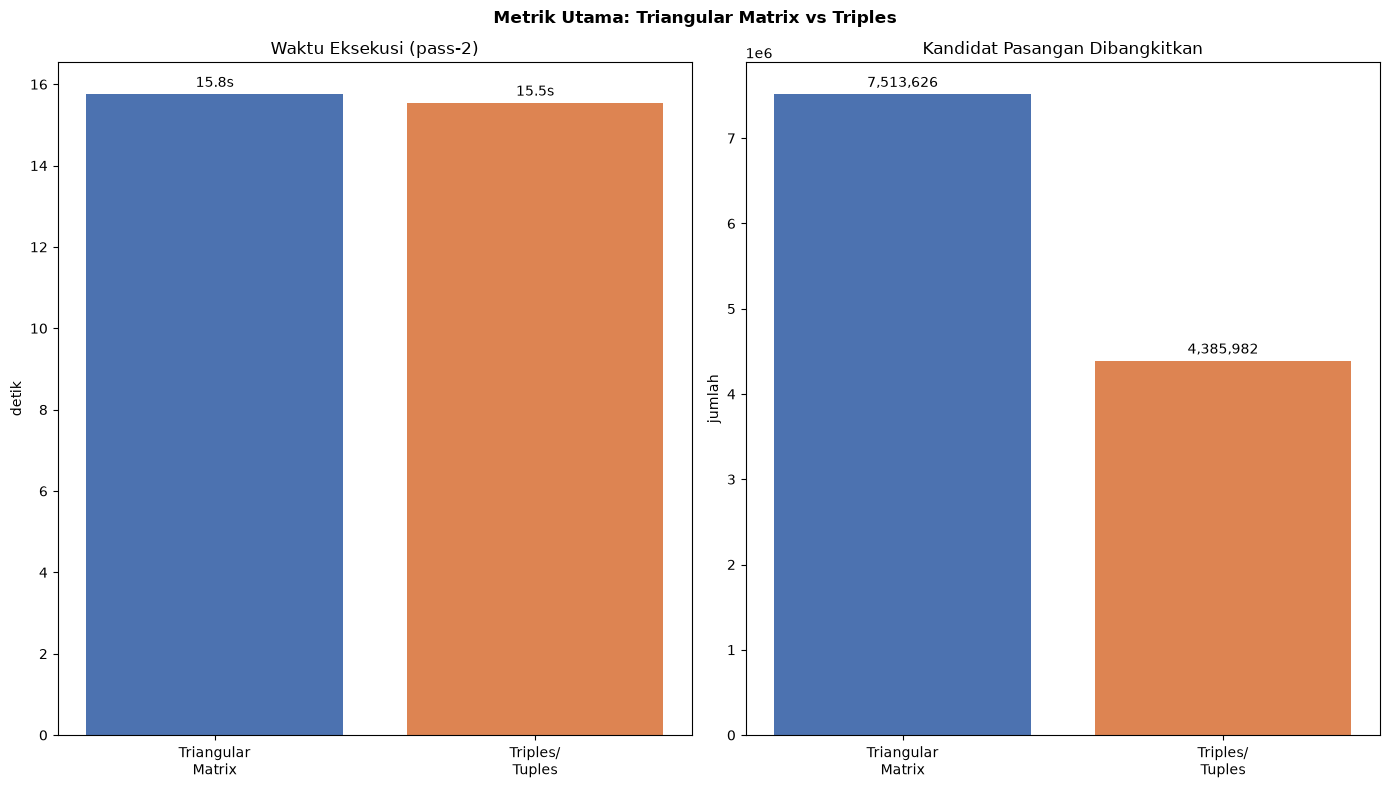

In [20]:
# Perbandingan tiga metrik inti antara kedua pendekatan
metode = ["Triangular\nMatrix", "Triples/\nTuples"]
warna = ["#4C72B0", "#DD8452"]

fig, axes = plt.subplots(1, 2, figsize=(14,8))

b0 = axes[0].bar(metode, [t_tri, t_trip], color=warna)
axes[0].set_title("Waktu Eksekusi (pass-2)"); axes[0].set_ylabel("detik")
axes[0].bar_label(b0, labels=[f"{t_tri:.1f}s", f"{t_trip:.1f}s"], padding=3)

b1 = axes[1].bar(metode, [tri_candidates, trip_candidates], color=warna)
axes[1].set_title("Kandidat Pasangan Dibangkitkan"); axes[1].set_ylabel("jumlah")
axes[1].bar_label(b1, labels=[f"{tri_candidates:,}", f"{trip_candidates:,}"], padding=3)

fig.suptitle("Metrik Utama: Triangular Matrix vs Triples", fontweight="bold")
fig.tight_layout()
plt.show()

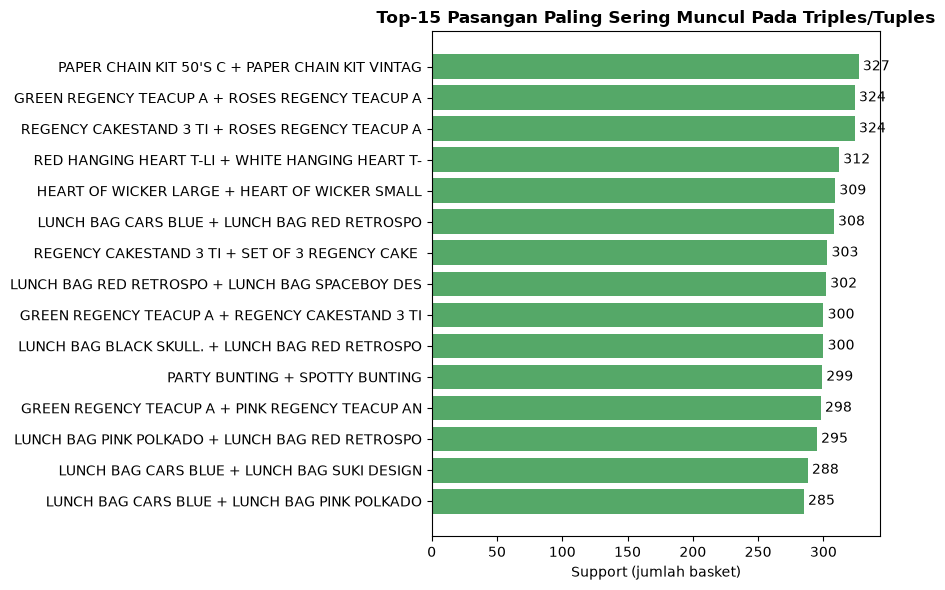

In [21]:
# Top-15 pasangan item paling sering muncul bersama
top15 = sorted(trip_frequent, key=lambda x: x[2], reverse=True)[:15]
label15 = [f"{a[:22]} + {b[:22]}" for a, b, _ in top15]
nilai15 = [c for _, _, c in top15]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(label15, nilai15, color="#55A868")
ax.invert_yaxis()
ax.set_xlabel("Support (jumlah basket)")
ax.set_title("Top-15 Pasangan Paling Sering Muncul Pada Triples/Tuples", fontweight="bold")
ax.bar_label(bars, padding=3)
fig.tight_layout()
plt.show()

## 5c. Top pasangan frequent per pendekatan (gambar terpisah)

Grafik Top-15 pasangan paling sering muncul, **dipisah** untuk tiap pendekatan: Pendekatan 1 (Triangular Matrix) dan Pendekatan 2 (Triples/Tuples). Keduanya menghitung hal yang sama sehingga hasilnya identik, namun ditampilkan pada gambar berbeda.


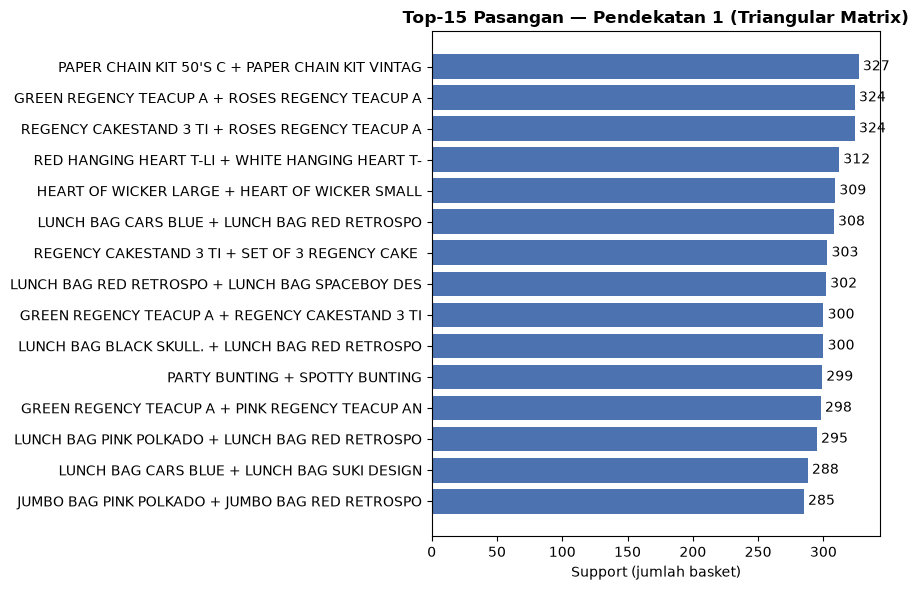

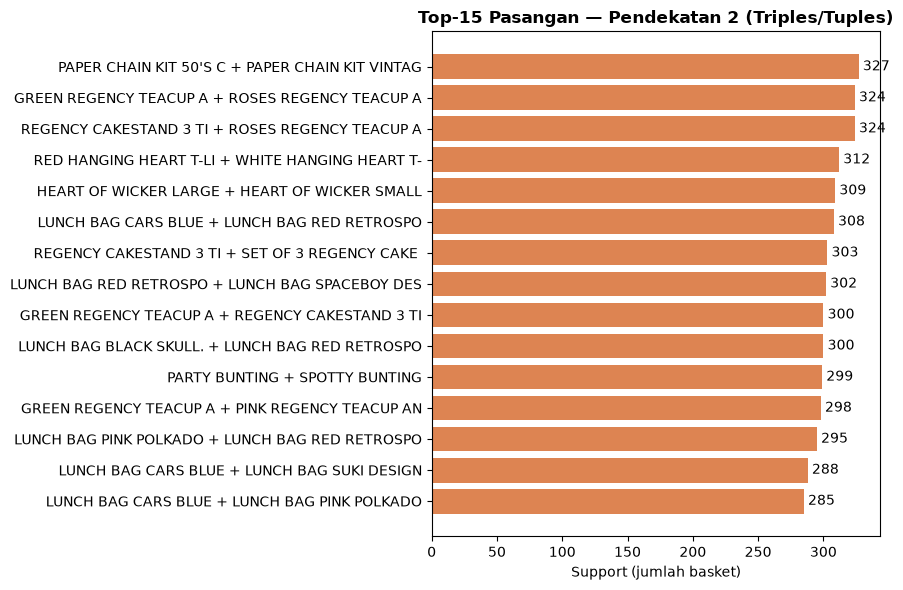

In [22]:
# Top pasangan frequent untuk masing-masing pendekatan -> dua gambar terpisah
TOP_N = 15

def plot_top_pairs(frequent, judul, warna):
    top = sorted(frequent, key=lambda x: x[2], reverse=True)[:TOP_N]
    label = [f"{a[:22]} + {b[:22]}" for a, b, _ in top]
    nilai = [c for *_, c in top]
    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(label, nilai, color=warna)
    ax.invert_yaxis()
    ax.set_xlabel("Support (jumlah basket)")
    ax.set_title(judul, fontweight="bold")
    ax.bar_label(bars, padding=3)
    fig.tight_layout()
    plt.show()

# --- Gambar 1: Pendekatan 1 (Triangular Matrix) ---
plot_top_pairs(tri_frequent, f"Top-{TOP_N} Pasangan — Pendekatan 1 (Triangular Matrix)", "#4C72B0")

# --- Gambar 2: Pendekatan 2 (Triples/Tuples) ---
plot_top_pairs(trip_frequent, f"Top-{TOP_N} Pasangan — Pendekatan 2 (Triples/Tuples)", "#DD8452")


## 5b. Penggunaan memori

Membandingkan memori struktur penghitung pasangan:

- **Triangular Matrix** → satu array `int32` berukuran $\binom{n}{2}$ sel, jadi memori = `tri.nbytes` (tetap, tak peduli berapa pasangan yang benar-benar muncul).
- **Triples/Tuples** → `dict` `(i, j) -> count`; memori diukur dari container `dict` ditambah ukuran tiap kunci `tuple` dan nilai `int`.

=== Penggunaan Memori ===
                   Kandidat pasangan  Memori (MB)  Byte / kandidat
Triangular Matrix            7513626        28.66             4.00
Triples/Tuples               4385982       544.82           130.25

Triangular Matrix : 30,054,504 byte (28.66 MB)
Triples/Tuples    : 571,282,592 byte (544.82 MB)


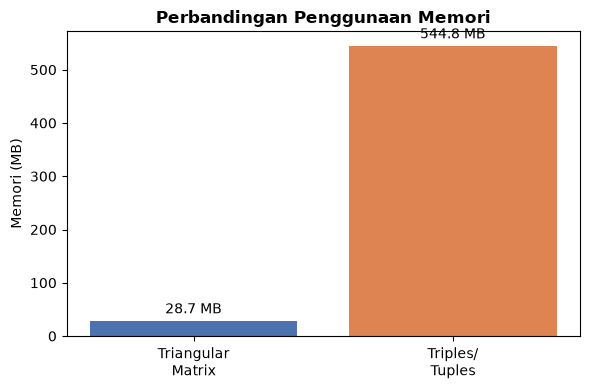

In [26]:
# Memori sudah dihitung di sel Pendekatan A (tri_mem) dan Pendekatan B (trip_mem)
MB = 1024 ** 2
mem_summary = pd.DataFrame(
    {
        "Kandidat pasangan": [tri_candidates, trip_candidates],
        "Memori (MB)": [round(tri_mem / MB, 2), round(trip_mem / MB, 2)],
        "Byte / kandidat": [
            round(tri_mem / tri_candidates, 2),
            round(trip_mem / trip_candidates, 2),
        ],
    },
    index=["Triangular Matrix", "Triples/Tuples"],
)

print("=== Penggunaan Memori ===")
print(mem_summary.to_string())
print(f"\nTriangular Matrix : {tri_mem:,} byte ({tri_mem / MB:.2f} MB)")
print(f"Triples/Tuples    : {trip_mem:,} byte ({trip_mem / MB:.2f} MB)")

# Grafik perbandingan memori
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ["Triangular\nMatrix", "Triples/\nTuples"],
    [tri_mem / MB, trip_mem / MB],
    color=["#4C72B0", "#DD8452"],
)
ax.set_ylabel("Memori (MB)")
ax.set_title("Perbandingan Penggunaan Memori", fontweight="bold")
ax.bar_label(bars, labels=[f"{tri_mem / MB:.1f} MB", f"{trip_mem / MB:.1f} MB"], padding=3)
fig.tight_layout()
plt.show()

## 8. Visualisasi struktur matriks pasangan (item i, item j)

Membandingkan **cara kedua pendekatan mengelompokkan pasangan (i, j)** pada matriks item×item (dipakai subset item terpopuler agar terbaca):

- **Pendekatan 1 — Triangular Matrix:** hanya sel **segitiga atas** ($i < j$) yang benar-benar disimpan; sel diagonal & segitiga bawah **tidak dipakai** (ditandai abu-abu).
- **Pendekatan 2 — Triples:** hanya titik pasangan $(i, j)$ yang **benar-benar muncul** yang disimpan (sel kosong tidak memakan tempat sama sekali).

Warna menyatakan besarnya *support* (jumlah basket) tiap pasangan.

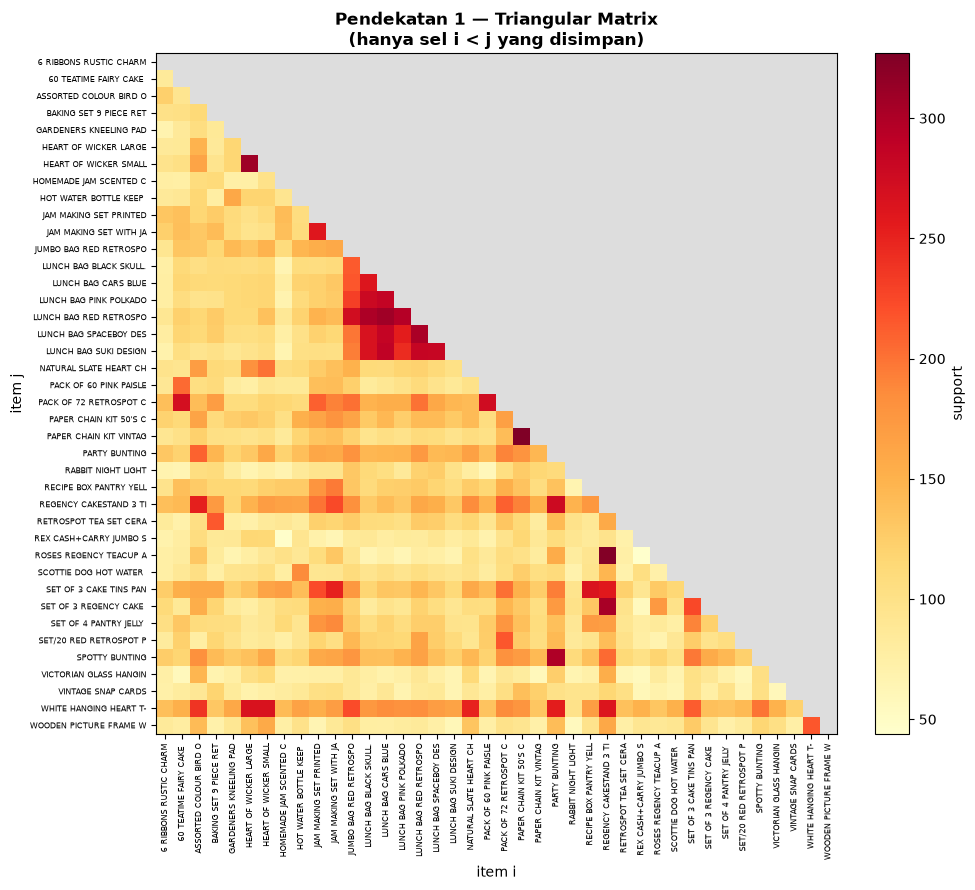

In [24]:
# Subset item terpopuler agar matriks item x item mudah dibaca
N_SHOW = 40
subset_ids = sorted(
    item_to_id[it] for it, _ in sorted(item_count.items(), key=lambda x: x[1], reverse=True)[:N_SHOW]
)
labels_sub = [items[k][:22] for k in subset_ids]

# Submatriks pasangan pada SEGITIGA BAWAH (r > c) -> orientasi konvensional
sub_low = np.zeros((N_SHOW, N_SHOW))
for r in range(N_SHOW):
    for c in range(r):  # c < r, kunci pasangan = (id kecil, id besar)
        sub_low[r, c] = pair_count.get((subset_ids[c], subset_ids[r]), 0)

# --- Pendekatan 1: Triangular Matrix (hanya sel i < j, digambar di segitiga bawah) ---
cmap = plt.cm.YlOrRd.copy()
cmap.set_bad(color="#dddddd")  # sel tak terpakai (segitiga atas & diagonal) -> abu-abu
tri_view = np.ma.masked_where(np.triu(np.ones_like(sub_low)) == 1, sub_low)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(tri_view, cmap=cmap)
ax.set_title("Pendekatan 1 — Triangular Matrix\n(hanya sel i < j yang disimpan)", fontweight="bold")
ax.set_xticks(range(N_SHOW)); ax.set_xticklabels(labels_sub, rotation=90, fontsize=6)
ax.set_yticks(range(N_SHOW)); ax.set_yticklabels(labels_sub, fontsize=6)
ax.set_xlabel("item i"); ax.set_ylabel("item j")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="support")
fig.tight_layout()
plt.show()

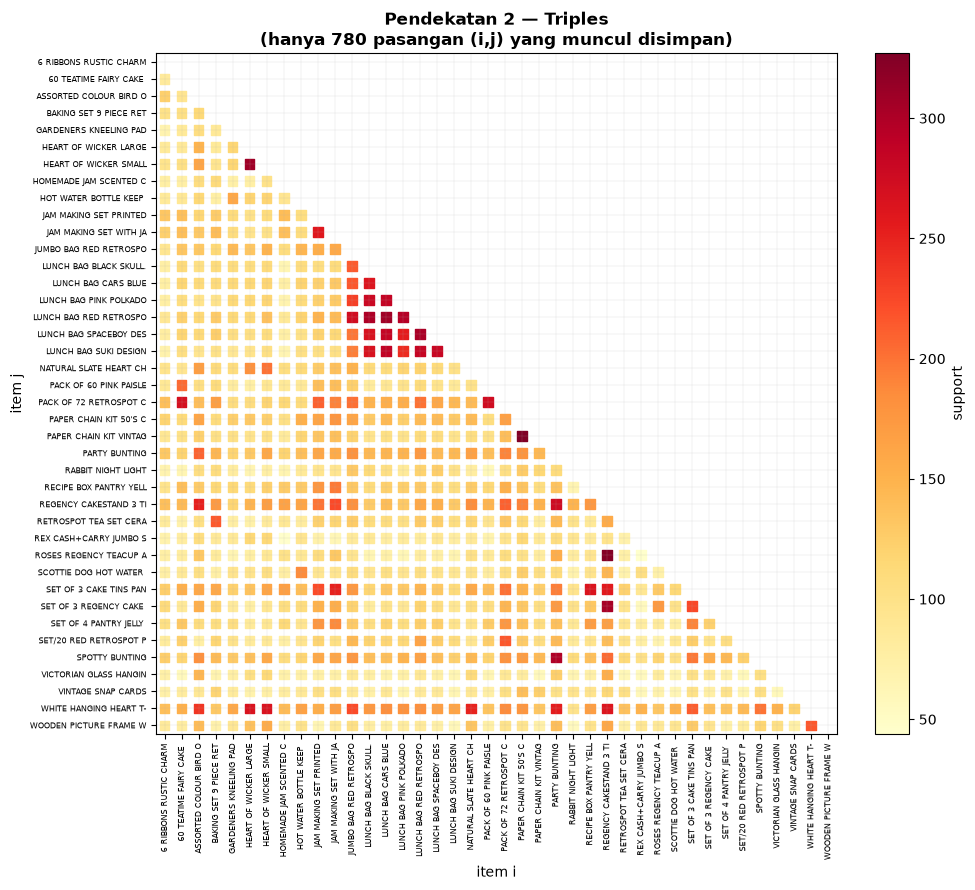

In [25]:
# --- Pendekatan 2: Triples (hanya pasangan (i,j) yang muncul, di segitiga bawah) ---
xs, ys, cs = [], [], []
for r in range(N_SHOW):
    for c in range(r):  # segitiga bawah
        if sub_low[r, c] > 0:
            xs.append(c); ys.append(r); cs.append(sub_low[r, c])

fig, ax = plt.subplots(figsize=(11, 9))
sc = ax.scatter(xs, ys, c=cs, cmap="YlOrRd", s=45, marker="s")
ax.set_xlim(-0.5, N_SHOW - 0.5); ax.set_ylim(N_SHOW - 0.5, -0.5)
ax.set_aspect("equal")
ax.set_title(f"Pendekatan 2 — Triples\n(hanya {len(xs)} pasangan (i,j) yang muncul disimpan)", fontweight="bold")
ax.set_xticks(range(N_SHOW)); ax.set_xticklabels(labels_sub, rotation=90, fontsize=6)
ax.set_yticks(range(N_SHOW)); ax.set_yticklabels(labels_sub, fontsize=6)
ax.set_xlabel("item i"); ax.set_ylabel("item j")
ax.grid(True, linewidth=0.3, alpha=0.4)
fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="support")
fig.tight_layout()
plt.show()